In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, TRANSITIONS_DIR
from src.utils.constants import EVENT_COLS
from src.features.passing import PASS_ANALYSIS_COLS
from src.features.possession import build_possession_summary
from src.features.transition import (
    build_transition_table,
    summarize_offensive_transitions,
    transition_win_zones,
    build_defensive_transition_table,
    summarize_defensive_transitions,
    summarize_transition_danger,
    transition_danger_by_response,
)
from src.visualization.transition import (
    plot_transition_response,
    plot_transition_win_zones,
    plot_transition_aggression,
    plot_defensive_reaction,
    plot_transition_danger,
    plot_transition_scatter,
)

MATCH_ID = 3749493
TEAMS = ["Arsenal", "Everton"]

In [2]:
from IPython.display import display

match_cols = sorted(set(EVENT_COLS + PASS_ANALYSIS_COLS + ["index", "possession"]))
events = pd.read_parquet(PROCESSED_DIR / "events_2004.parquet", columns=match_cols)
match_df = events[events["match_id"] == MATCH_ID].copy()

match_info = (
    pd.read_csv(PROCESSED_DIR / "matches_2004.csv")
    .loc[lambda d: d["match_id"] == MATCH_ID]
    .iloc[0]
)
print(
    f"{match_info['match_home_team']} {match_info['match_score']} "
    f"{match_info['match_away_team']} \u2014 {match_info['match_kickoff']}"
)

possession_summary = build_possession_summary(match_df)

# Transition tables used throughout this notebook
transitions = build_transition_table(match_df, possession_summary)
off_summary = summarize_offensive_transitions(transitions, TEAMS)
win_zones = transition_win_zones(transitions, TEAMS)
def_transitions = build_defensive_transition_table(match_df)
def_summary = summarize_defensive_transitions(def_transitions, TEAMS)
danger = summarize_transition_danger(transitions, possession_summary, TEAMS)
danger_by_response = transition_danger_by_response(transitions, TEAMS)

n_ars = int((transitions["team"] == "Arsenal").sum())
n_eve = int((transitions["team"] == "Everton").sum())
print(f"Open-play transitions: {len(transitions)}  (Arsenal {n_ars}, Everton {n_eve})")

Arsenal 2 - 1 Everton — 2003-08-16 13:00:00.000
Open-play transitions: 68  (Arsenal 37, Everton 31)


<hr>

# Winning it and losing it: the transition game
## A transition case study — Arsenal 2–1 Everton (16 Aug 2003)

### Abstract

Much of football's decisive action happens in the few seconds *around* a change of possession — the transition. Modern, possession-based sides tend to treat winning the ball as the start of a controlled rebuild and losing it as a trigger to win it straight back; older, more direct sides tend to attack immediately on winning and drop off on losing. Using StatsBomb event data from a single fixture (`match_id` 3749493, the opener of Arsenal's unbeaten 2003/04 season), this notebook profiles both sides' **offensive and defensive transitions** and tests whether they split along that line.

### Hypothesis

> **H1 — In transition, Arsenal *rebuild control* while Everton *attack and press*.** On winning the ball Arsenal should regain it deeper, secure it, and progress gradually; on losing it they should drop and recover shape. Everton should win the ball higher, break vertically and fast, and counterpress aggressively to win it straight back.

We treat H1 as four testable questions, each a section below:

| Section | Question | If H1 holds, we expect… |
|---|---|---|
| **1 After winning** | What do teams do immediately after winning possession? | Arsenal: win deep, secure/recycle first. Everton: win higher, attack first. |
| **2 Aggression** | How aggressively do they transition into attack? | Arsenal: gradual territory gain. Everton: faster, more vertical, reach final third sooner. |
| **3 After losing** | How do they react after losing possession? | Arsenal: drop and recover shape (low counterpress). Everton: counterpress immediately. |
| **4 Danger** | Which transitions become dangerous? | Everton more transition-reliant for chances; Arsenal create more from sustained possession. |

Each section closes with a **verdict**; Section 5 synthesises them. As with the possession and passing notebooks, this is a **single-match case study** — it can support H1 for this fixture but cannot prove a season-long tendency.

<hr>

## Methods — defining a transition

A **transition** here is an *open-play change of possession*: a possession whose `play_pattern` is `Regular Play` or `From Counter` and whose immediately preceding possession belonged to the **other** team. Set-piece restarts (throw-in, free kick, goal kick, corner, keeper, kick-off) are excluded — they are not live turnovers. StatsBomb conveniently includes the ball-winning action (Ball Recovery / Duel / Interception) as the first event of the new possession, so the start of such a possession marks the moment the ball was won.

Key definitions:

- **First action** — the possession team's first `Pass` or `Carry`. Classified by forward distance `dx = end_x - start_x`: **attack** (`dx ≥ 5`), **recycle back** (`dx ≤ -5`), or **secure** (in between). A first pass ≥ 30 m is flagged as an immediate long ball.
- **Win zone** — pitch third where the ball was won (`defensive < 40 ≤ middle < 80 ≤ attacking`).
- **Aggression** — territory (max x reached minus start x) gained in the first **10 s**, plus whether/when the move reaches the final third.
- **Defensive transition** — for the team that just *lost* the ball: did it **counterpress**, and did it produce any defensive action (Pressure, Duel, Ball Recovery, Interception, Block, Clearance, Foul) within **5 s**? Plus the territory it conceded in that window.
- **Danger** — each transition possession's box entries, shots and xG, compared against the team's non-transition possessions.

<hr>

## 1. What teams do after winning possession

**Prediction (H1).** Arsenal should win the ball deeper and answer with a securing or recycling action; Everton should win it higher and attack on the first action.

Response to winning the ball (open play):


,team,transitions,attack_pct,secure_pct,recycle_back_pct,first_long_pct
0,Arsenal,37,45.9,37.8,16.2,2.7
1,Everton,31,41.9,29.0,29.0,0.0



Where the ball is won (% of open-play wins):


team,Arsenal,Everton
win_zone,,
defensive,78.4,38.7
middle,18.9,61.3
attacking,2.7,0.0


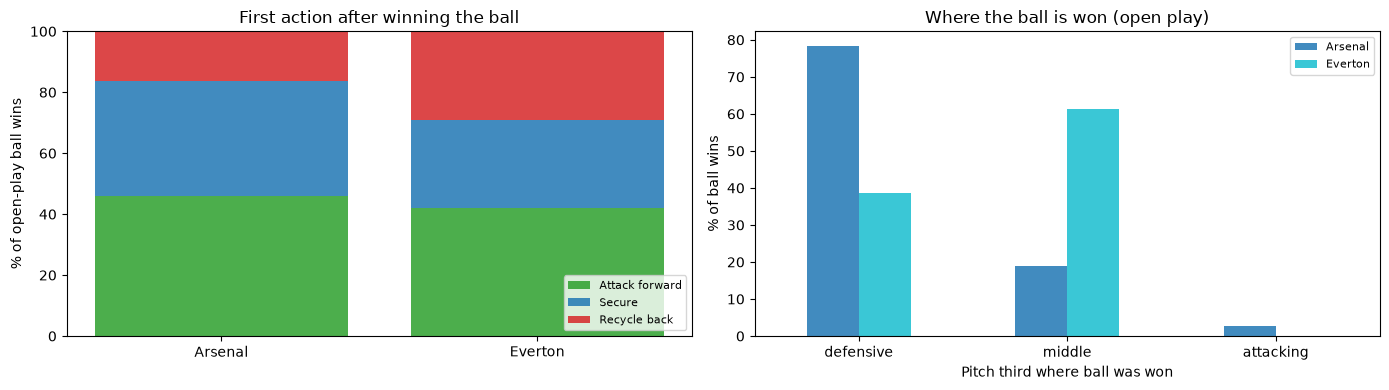

In [3]:
print("Response to winning the ball (open play):")
display(off_summary[["team", "transitions", "attack_pct", "secure_pct", "recycle_back_pct", "first_long_pct"]].round(1))

print("\nWhere the ball is won (% of open-play wins):")
display(
    win_zones.pivot(index="win_zone", columns="team", values="pct")
    .reindex(["defensive", "middle", "attacking"]).round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_transition_response(off_summary, ax=axes[0])
plot_transition_win_zones(win_zones, ax=axes[1])
plt.tight_layout()
plt.show()

**Findings.** The two sides win the ball in very different places. Arsenal regain it deep — **78%** of their open-play wins come in their own defensive third, only 19% in midfield and one in the attacking third — the profile of a team that drops into a block and recovers the ball behind the ball. Everton win it markedly higher: **61%** in midfield and 39% in their defensive third (none in the attacking third).

The *first action*, though, is more even than the caricature suggests. Both attack at similar rates (Arsenal 46%, Everton 42% play a significant forward first action). The difference lies in the alternative: Arsenal more often **secure** (38% vs 29%), while Everton more often **recycle backwards** (29% vs 16%). Immediate long balls straight off the win are rare for both (≤ 3%).

**Verdict — partially supports H1.** The *where* splits exactly as predicted (Everton press higher, Arsenal regain deep), but the *what-first* does not: neither side launches it immediately, and Everton actually reset backwards more often — plausibly because they win it under pressure in central areas and must stabilise before breaking.

<hr>

## 2. How aggressively teams transition into attack

**Prediction (H1).** Once moving, Everton should gain territory faster and reach the final third sooner and more often; Arsenal should advance more gradually.

,team,median_territory_10s,mean_territory_10s,reached_final_third_pct,median_time_to_final_third,median_directness
0,Arsenal,30.7,32.72,56.76,9.0,0.45
1,Everton,30.5,36.27,74.19,7.0,0.46


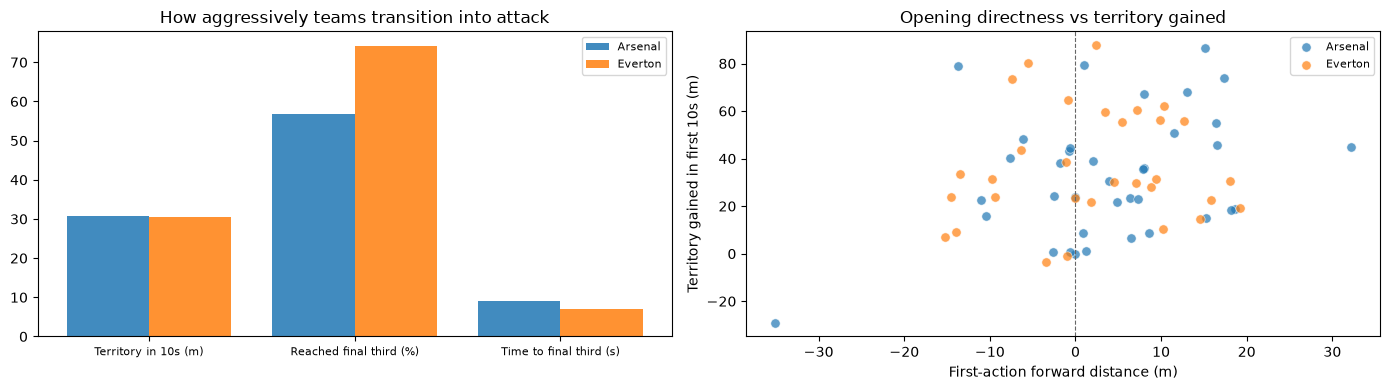

In [4]:
display(
    off_summary[[
        "team", "median_territory_10s", "mean_territory_10s",
        "reached_final_third_pct", "median_time_to_final_third", "median_directness",
    ]].round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_transition_aggression(off_summary, ax=axes[0])
plot_transition_scatter(transitions, TEAMS, ax=axes[1])
plt.tight_layout()
plt.show()

**Findings.** Everton's transitions are more vertical. They reach the final third on **74%** of transitions versus Arsenal's **57%**, and get there faster (median **7 s** vs **9 s**). Median territory gained in the first 10 seconds is similar (~31 m), but Everton's mean is higher (36 vs 33 m), reflecting a longer tail of fast, ground-eating breaks; their opening forward distance is slightly higher too.

**Verdict — supports H1.** Everton's transitions travel further forward, faster, and reach the final third more often — the direct vertical break — while Arsenal advance more gradually.

<hr>

## 3. How teams react after losing possession

**Prediction (H1).** After losing the ball Everton should counterpress immediately; Arsenal should more often decline the press and drop to recover shape.

,team,losses,counterpress_pct,def_action_5s_pct,median_time_to_def_action,median_territory_conceded_5s,mean_territory_conceded_5s,lost_in_att_third_pct
0,Arsenal,31,38.71,48.39,2.0,21.8,20.38,0.00
1,Everton,38,73.68,76.32,2.0,21.0,21.33,2.63


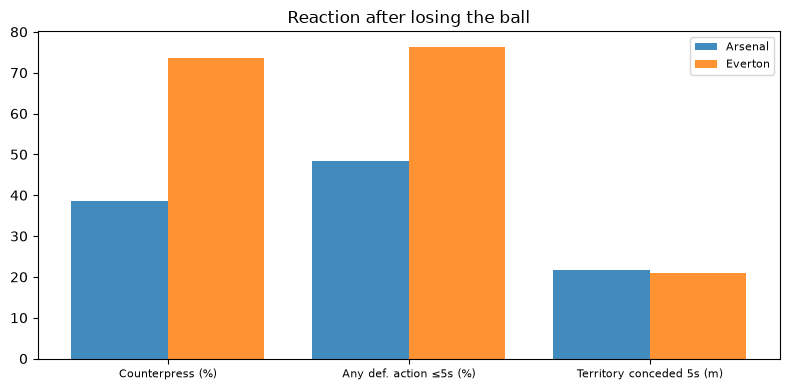

In [5]:
display(def_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
plot_defensive_reaction(def_summary, ax=ax)
plt.tight_layout()
plt.show()

**Findings.** This is the sharpest split in the notebook. After losing the ball, **Everton counterpress on 74% of losses** and produce some defensive action within 5 seconds on **76%**; **Arsenal counterpress on only 39%** and react within 5 s on **48%**. When either side does act, it acts quickly (~2 s). Territory conceded in the first 5 seconds is near-identical (~21 m), so in this match the counterpress is about *intent to win the ball back* rather than territory actually saved.

**Verdict — strongly supports H1.** Everton chase the ball immediately on losing it — an aggressive, gegenpress-like defensive transition — whereas Arsenal far more often decline the counterpress and drop to recover shape, the controlled, risk-averse reaction.

<hr>

## 4. Which transitions become dangerous

**Prediction (H1).** Everton should be more transition-reliant for chances; Arsenal should manufacture more of their danger from sustained (non-transition) possession.

Transition vs other possessions:


,team,possession_type,possessions,shot_pct,box_entry_pct,final_third_pct,total_xg,xg_per_possession
0,Arsenal,transition,37,5.405,24.324,56.757,0.135,0.004
1,Arsenal,other,68,13.235,29.412,75.000,1.986,0.029
2,Everton,transition,31,6.452,38.710,74.194,0.449,0.014
3,Everton,other,65,16.923,47.692,90.769,0.819,0.013



Danger by first-response type (small samples — read directionally):


,team,response,transitions,box_entry_pct,shot_pct,total_xg
0,Arsenal,attack,17,23.529,5.882,0.028
1,Arsenal,secure,14,21.429,0.000,0.000
2,Arsenal,recycle_back,6,33.333,16.667,0.106
3,Everton,attack,13,30.769,0.000,0.000
4,Everton,secure,9,55.556,11.111,0.441
5,Everton,recycle_back,9,33.333,11.111,0.008


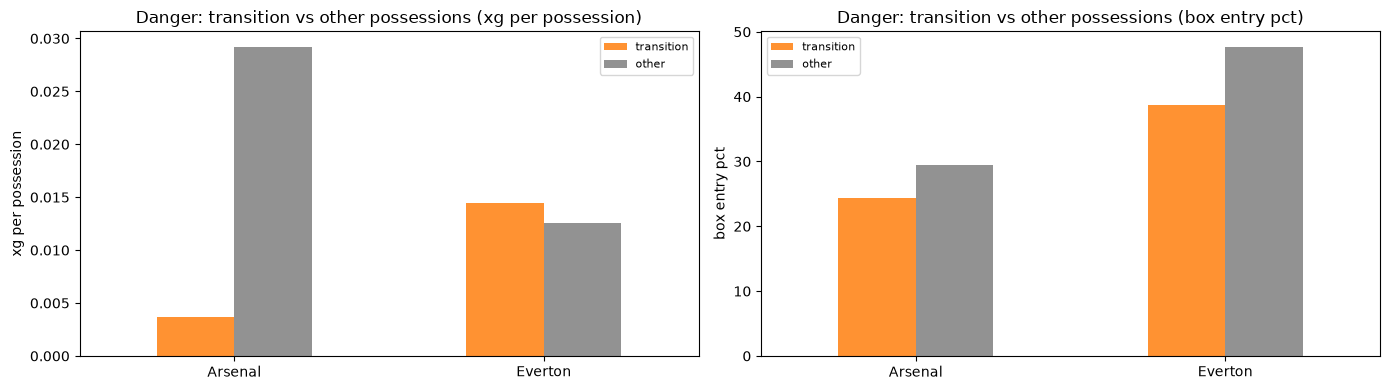

In [4]:
print("Transition vs other possessions:")
display(danger.round(3))

print("\nDanger by first-response type (small samples — read directionally):")
display(danger_by_response.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_transition_danger(danger, metric="xg_per_possession", ax=axes[0])
plot_transition_danger(danger, metric="box_entry_pct", ax=axes[1])
plt.tight_layout()
plt.show()

**Findings.** The two teams draw danger from different possession types. Arsenal's xG comes overwhelmingly from **non-transition** possessions (**0.029** xG per possession vs just **0.004** from transitions): their threat is built, not sprung. Everton are far more balanced — transitions (**0.014** xG/possession) are about as productive as their other possessions (**0.013**) and reach the box more often (**39%** of transitions vs Arsenal's **24%**). Splitting by first-response type is noisy at this sample size (a single chance swings the totals), so we read it only directionally.

**Verdict — supports H1, with nuance.** Everton are the more transition-reliant attacking side; Arsenal manufacture their best chances through sustained possession rather than the quick break. This dovetails with the possession notebook — Arsenal's edge is controlled build-up, Everton's is the transition.

<hr>

## 5. Discussion and conclusion

**Does the evidence support H1?** Largely yes, with one refinement.

**Where H1 holds clearly**
- *Where the ball is won (S1).* Arsenal regain deep (78% defensive third); Everton win higher (61% midfield).
- *Aggression (S2).* Everton reach the final third more often (74% vs 57%) and faster (7 s vs 9 s) — the vertical break.
- *Defensive transition (S3).* Everton counterpress on 74% of losses vs Arsenal's 39% — the standout contrast: chase vs drop-and-shape.
- *Danger (S4).* Arsenal's xG is built from sustained possession (0.029 vs 0.004 xG/possession in transition); Everton are transition-balanced and enter the box more from transitions.

**Where the picture needs refining**
- The *first action after winning* is more even than "rushed vs controlled" implies: both attack immediately at similar rates (~42–46%), and Everton actually **recycle backwards more** (29% vs 16%), likely because they win the ball under pressure centrally and must stabilise before going. The divergence is in *where* they win, *how fast* they then break, and *how hard* they counterpress — not in a simple launch-it-or-not split on the first touch.

**Conclusion.** For this fixture, **H1 is supported.** Arsenal treat the transition as the start of a controlled rebuild — winning deep, advancing gradually, and recovering shape rather than counterpressing — while Everton treat it as a moment to strike: winning higher, breaking vertically and fast, and pressing immediately to win the ball back. The two transition profiles are a clean continuation of the controlled-vs-direct identities established in the possession and passing notebooks.

**Limitations.** Single match, so this illustrates rather than proves a tendency; several cuts have small samples (68 transitions total; danger-by-response especially); counterpress and territory are measured in fixed 5 s / 10 s windows; and transitions are defined via StatsBomb possession boundaries, which occasionally split or merge phases. Replicating across the full 2003/04 season is the natural next step.